In [2]:
import sys
!{sys.executable} -m pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 8.3 MB/s  0:00:27 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 18.8 MB/s  0:00:00 eta 0:00:01:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 6.6 MB/s  0:00:00m 6.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 14.1 MB/s  0:00:00
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 9.7 MB/s  0:00:02m 9.3 MB/s eta 0:00:01m
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)
Using cached mdurl

Loading 3D datasets...
Data loaded successfully! X_train shape: (217668, 60, 16)

Starting LSTM Training. This may take a few minutes on the M1...
Epoch 1/20
3061/3061 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8524 - loss: 0.4198 - val_accuracy: 0.5369 - val_loss: 0.9749
Epoch 2/20
3061/3061 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.8533 - loss: 0.4165 - val_accuracy: 0.5369 - val_loss: 0.9541
Epoch 3/20
3061/3061 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.8533 - loss: 0.4148 - val_accuracy: 0.5369 - val_loss: 1.1031
Epoch 4/20
3061/3061 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.8533 - loss: 0.4130 - val_accuracy: 0.5369 - val_loss: 0.9454
Epoch 5/20
3061/3061 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.8533 - loss: 0.4123 - val_accuracy: 0.5369 - val_loss: 0.9593
Epoch 6/20
3061/3061 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.8533 - loss: 0.4091 - val_accuracy: 0.5369 - val_loss: 1.0401
Epoch 7/20
3061/3061 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - acc

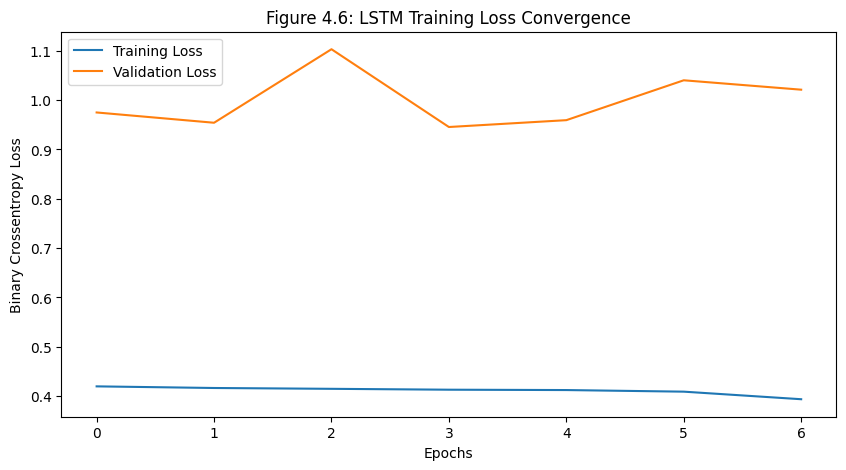


Predicting on Test Set...
1700/1700 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

--- LSTM CHALLENGER RESULTS FOR SECTION 4.4 ---
Total Training Time: 277.2686 seconds
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     54372

    accuracy                           1.00     54372
   macro avg       1.00      1.00      1.00     54372
weighted avg       1.00      1.00      1.00     54372



In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import time
from sklearn.metrics import classification_report

print("Loading 3D datasets...")
X_train = np.load('../data/processed/X_train_lstm.npy')
y_train = np.load('../data/processed/y_train_lstm.npy')
X_test = np.load('../data/processed/X_test_lstm.npy')
y_test = np.load('../data/processed/y_test_lstm.npy')

print(f"Data loaded successfully! X_train shape: {X_train.shape}")

model = Sequential([
    
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2), 
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') 
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nStarting LSTM Training. This may take a few minutes on the M1...")
start_time = time.time()

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

train_time_lstm = time.time() - start_time

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Figure 4.6: LSTM Training Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.savefig('../figures/Figure_4_6_LSTM_Training_History.png')
plt.show()

print("\nPredicting on Test Set...")

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

print(f"\n--- LSTM CHALLENGER RESULTS FOR SECTION 4.4 ---")
print(f"Total Training Time: {train_time_lstm:.4f} seconds")
print(classification_report(y_test, y_pred))